# Clustering -  Empleados

Objetivo:  
Conocer las características regionales de los aspirantes para diseñar las estrategias de mercadeo.



1. Preparación de datos: variables numéricas se deben normalizar y variables categóricas se crean dummies
2. Aprendizaje del Modelo: Kmeans, método del codo
3. Evaluación del Modelo: Inertia, silueta
4. Perfilamiento: Descripción de centroides



In [5]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos

* Previa limpieza de atípicos, nulos y altas correlaciones









In [6]:
# Se cargan los datos
df = pd.read_excel("Admisiones_Posgrado_salud.xlsx",sheet_name="Datos") #Cargar datos en excel
df.head() #muestras los 5 primeros registros

,Periodo,Programa Admision,Presentan examen,Fecha Registro Admision,Estado Pago,Genero,Edad,Pais Nacimiento,Tipo Documento,Departamento Nacimiento,Ciudad Residencia,Naturaleza Origen Universidad
0,202142,Esp en Psiquiatria-Med,SI,2020-10-05 07:45:21,Pago de admision,M,41,Colombia,CC,Santander-CO,ENVIGADO - ANTIOQUIA,Publica
1,202142,Esp Medicina Interna-Med,SI,2020-08-31 08:03:03,Pago de admision,M,35,Colombia,CC,Antioquia-CO,ENVIGADO - ANTIOQUIA,Privada
2,202142,Esp Med Dol y Cui Pal-Med,SI,2020-10-02 08:10:40,Pago de admision,M,43,Colombia,CC,Norte Santander-CO,SABANETA - ANTIOQUIA,Privada
3,202142,Esp Dermatologia-Med,SI,2020-10-06 11:38:21,Pago de admision,M,36,Colombia,CC,Antioquia-CO,ENVIGADO - ANTIOQUIA,Publica
4,202142,Esp Radiologia e Imag Diag-Med,SI,2020-09-11 09:01:34,Pago de admision,M,35,Colombia,CC,Antioquia-CO,MEDELLIN - ANTIOQUIA,Privada


In [7]:
#Se revisan los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9188 entries, 0 to 9187
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Periodo                        9188 non-null   int64         
 1   Programa Admision              9188 non-null   object        
 2   Presentan examen               9188 non-null   object        
 3   Fecha Registro Admision        9188 non-null   datetime64[ns]
 4   Estado Pago                    9188 non-null   object        
 5   Genero                         9188 non-null   object        
 6   Edad                           9188 non-null   int64         
 7   Pais Nacimiento                9188 non-null   object        
 8   Tipo Documento                 9188 non-null   object        
 9   Departamento Nacimiento        9188 non-null   object        
 10  Ciudad Residencia              9188 non-null   object        
 11  Naturaleza Origen

* Transformaciones: normalizar y crear dummies

In [8]:
#Copia de los datos
data=df.copy()

In [9]:
#Corrección tipos de datos
data['Programa Admision']=data['Programa Admision'].astype('category')
data['Presentan examen']=data['Presentan examen'].astype('category')
data['Estado Pago']=data['Estado Pago'].astype('category')
data['Genero']=data['Genero'].astype('category')
data['Pais Nacimiento']=data['Pais Nacimiento'].astype('category')
data['Tipo Documento']=data['Tipo Documento'].astype('category')
data['Departamento Nacimiento']=data['Departamento Nacimiento'].astype('category')
data['Naturaleza Origen Universidad']=data['Naturaleza Origen Universidad'].astype('category')
data['Ciudad Residencia']=data['Ciudad Residencia'].astype('category')
data['Periodo']=data['Periodo'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9188 entries, 0 to 9187
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Periodo                        9188 non-null   category      
 1   Programa Admision              9188 non-null   category      
 2   Presentan examen               9188 non-null   category      
 3   Fecha Registro Admision        9188 non-null   datetime64[ns]
 4   Estado Pago                    9188 non-null   category      
 5   Genero                         9188 non-null   category      
 6   Edad                           9188 non-null   int64         
 7   Pais Nacimiento                9188 non-null   category      
 8   Tipo Documento                 9188 non-null   category      
 9   Departamento Nacimiento        9188 non-null   category      
 10  Ciudad Residencia              9188 non-null   category      
 11  Naturaleza Origen

In [10]:
#descripcion estadistica de variables numericas
df.describe()

,Periodo,Fecha Registro Admision,Edad
count,9188.000000,9188,9188.000000
mean,202414.703526,2023-05-26 09:41:57.156726272,32.107096
min,202142.000000,2020-05-18 09:05:45,21.000000
25%,202242.000000,2021-09-13 07:44:14,29.000000
50%,202442.000000,2023-07-26 10:28:55,32.000000
75%,202542.000000,2024-09-23 10:17:29,34.000000
max,202742.000000,2026-09-09 11:41:05,59.000000
std,195.746109,NaN,4.259752


array([[<Axes: title={'center': 'Periodo'}>,
        <Axes: title={'center': 'Fecha Registro Admision'}>],
       [<Axes: title={'center': 'Edad'}>, <Axes: >]], dtype=object)

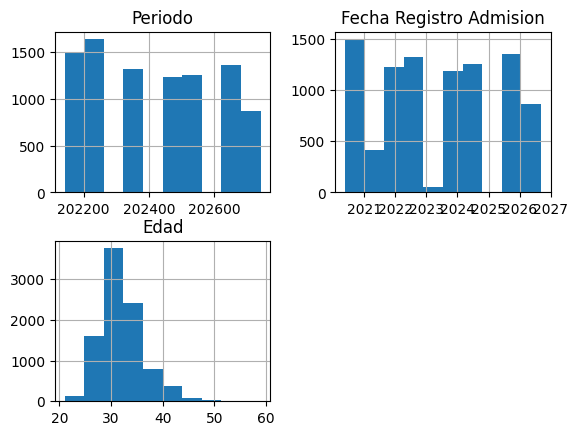

In [11]:
#hiostogramas de las variables numericas
df.hist()

<Axes: >

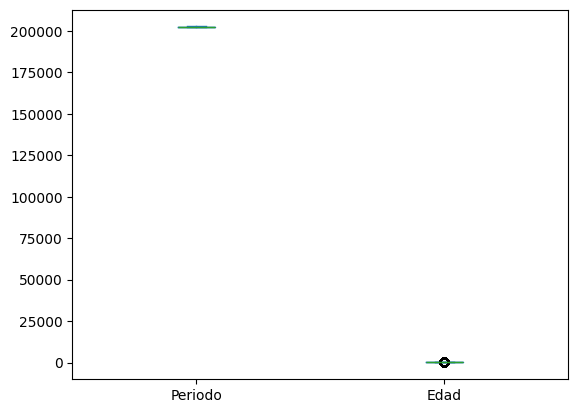

In [12]:
#graficos box variables numericas
df.plot(kind='box')

<Axes: >

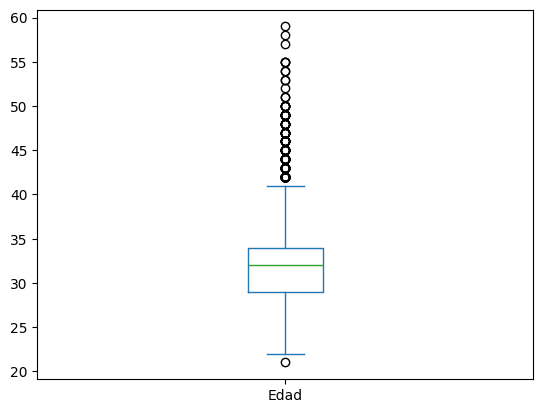

In [13]:
#grafico box incapacidades
df['Edad'].plot(kind='box')

<Axes: xlabel='Estado Pago'>

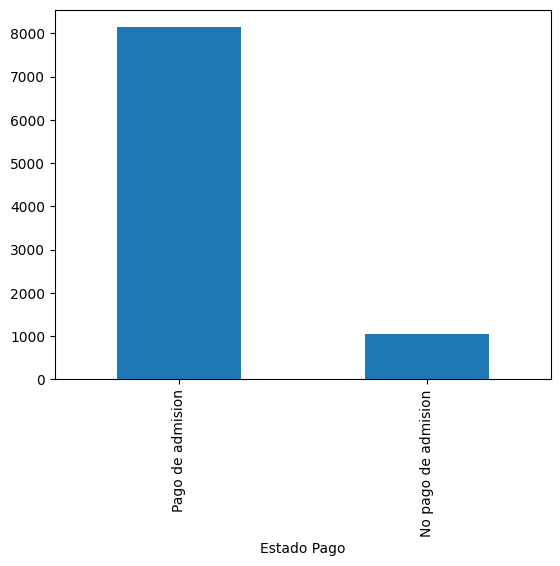

In [14]:
#Conocemos las variables categóricas: value_counts()
df['Estado Pago'].value_counts().plot(kind='bar')

<Axes: ylabel='Genero'>

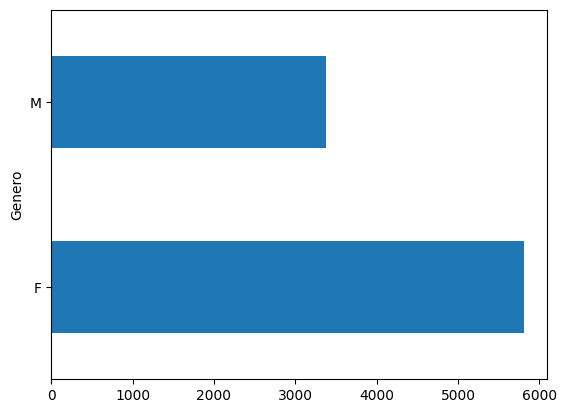

In [15]:
df['Genero'].value_counts().plot(kind='barh')

<Axes: ylabel='count'>

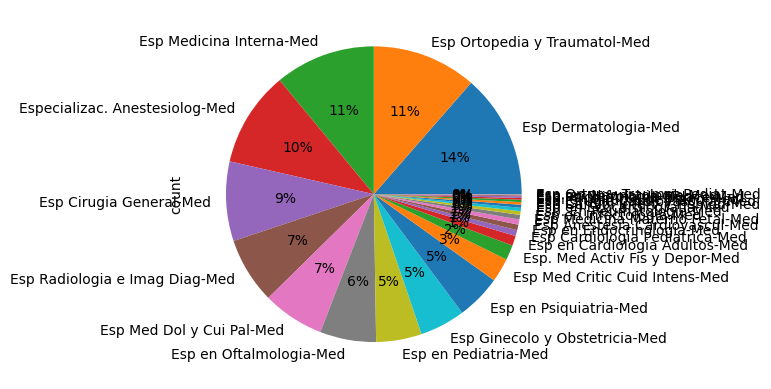

In [16]:
#Gráfico para variables categóricas
df['Programa Admision'].value_counts().plot(kind='pie',autopct='%.0f%%')

<Axes: ylabel='count'>

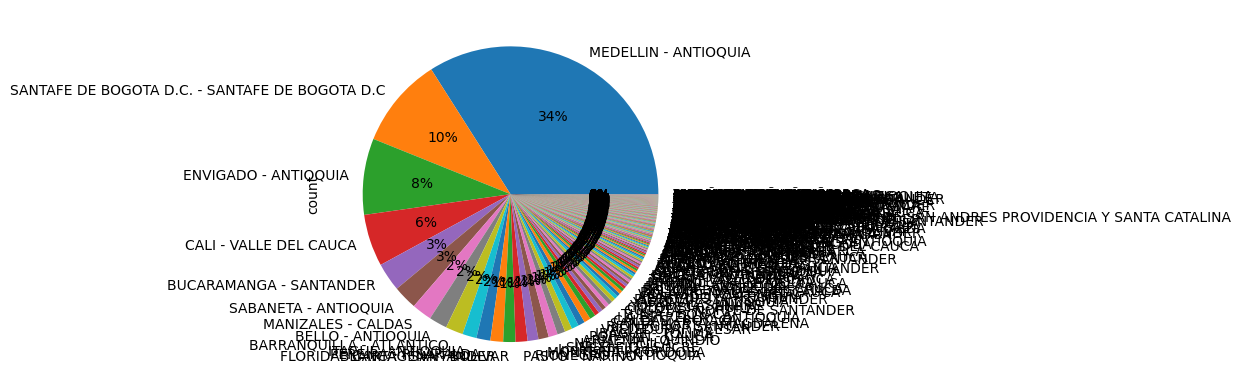

In [17]:
#Gráfico para variables categóricas
df['Ciudad Residencia'].value_counts().plot(kind='pie',autopct='%.0f%%')

In [18]:
# Cargar librería para Profiling
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.3 MB/s eta 0:00:00


In [20]:
# Perfilado de datos
from ydata_profiling import ProfileReport

profile_data=ProfileReport(df, minimal=True) # minimal=False
profile_data

/tmp/ipykernel_1531/1704262744.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 66.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Transformaciones: normalizar y crear dummies

In [22]:
#Copia de los datos
data=df.copy()

#No se hace balanceo porque no hay variable objetivo

In [24]:

#Normalizacion de variables numérica
from sklearn.preprocessing import MinMaxScaler


variables_a_normalizar=['Edad'] #variables numéricas

min_max_scaler = MinMaxScaler()

min_max_scaler.fit(data[variables_a_normalizar]) #Ajuste de parámetro
data[variables_a_normalizar]= min_max_scaler.transform(data[variables_a_normalizar])
data.head()

,Periodo,Programa Admision,Presentan examen,Fecha Registro Admision,Estado Pago,Genero,Edad,Pais Nacimiento,Tipo Documento,Departamento Nacimiento,Ciudad Residencia,Naturaleza Origen Universidad
0,202142,Esp en Psiquiatria-Med,SI,2020-10-05 07:45:21,Pago de admision,M,0.526316,Colombia,CC,Santander-CO,ENVIGADO - ANTIOQUIA,Publica
1,202142,Esp Medicina Interna-Med,SI,2020-08-31 08:03:03,Pago de admision,M,0.368421,Colombia,CC,Antioquia-CO,ENVIGADO - ANTIOQUIA,Privada
2,202142,Esp Med Dol y Cui Pal-Med,SI,2020-10-02 08:10:40,Pago de admision,M,0.578947,Colombia,CC,Norte Santander-CO,SABANETA - ANTIOQUIA,Privada
3,202142,Esp Dermatologia-Med,SI,2020-10-06 11:38:21,Pago de admision,M,0.394737,Colombia,CC,Antioquia-CO,ENVIGADO - ANTIOQUIA,Publica
4,202142,Esp Radiologia e Imag Diag-Med,SI,2020-09-11 09:01:34,Pago de admision,M,0.368421,Colombia,CC,Antioquia-CO,MEDELLIN - ANTIOQUIA,Privada


In [26]:
# Se crean dummies para las variables de 2 categorías
data = pd.get_dummies(data, columns=['Periodo', 'Programa Admision', 'Presentan examen','Estado Pago','Genero','Pais Nacimiento','Tipo Documento','Departamento Nacimiento','Ciudad Residencia','Naturaleza Origen Universidad'], drop_first=True, dtype=int)
data.head()

,Fecha Registro Admision,Edad,Periodo_202242,Periodo_202342,Periodo_202442,Periodo_202542,Periodo_202642,Periodo_202742,Programa Admision_Esp Cardiol Interv y Hemod-Med,Programa Admision_Esp Cardiologia Pediatrica-Med,...,Ciudad Residencia_YACUANQUER - NARIÑO,Ciudad Residencia_YARUMAL - ANTIOQUIA,Ciudad Residencia_YOLOMBO - ANTIOQUIA,Ciudad Residencia_YOPAL - CASANARE,Ciudad Residencia_YUMBO - VALLE DEL CAUCA,Ciudad Residencia_ZARZAL - VALLE DEL CAUCA,Ciudad Residencia_ZIPAQUIRA - CUNDINAMARCA,Ciudad Residencia_ZONA BANANERA - MAGDALENA,Naturaleza Origen Universidad_Privada,Naturaleza Origen Universidad_Publica
0,2020-10-05 07:45:21,0.526316,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2020-08-31 08:03:03,0.368421,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2020-10-02 08:10:40,0.578947,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,2020-10-06 11:38:21,0.394737,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2020-09-11 09:01:34,0.368421,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


# 2. Aprendizaje del Modelo
* Metodo del codo
* Aplicar kmeans

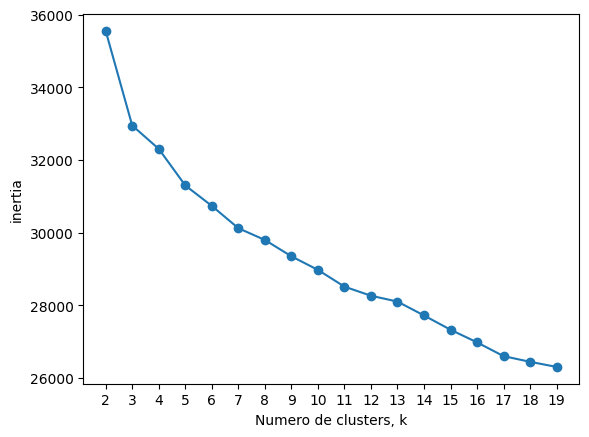

In [28]:
#Método del codo para encontrar la mejor cantidad de clusters: inertia
from sklearn.cluster import KMeans

ks = range(2, 20) # crear valores del 2 al 20
inertias = []

data_for_kmeans = data.drop('Fecha Registro Admision', axis=1)

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k,max_iter=300, random_state=42, n_init='auto')
    model.fit(data_for_kmeans)
    inertias.append(model.inertia_)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

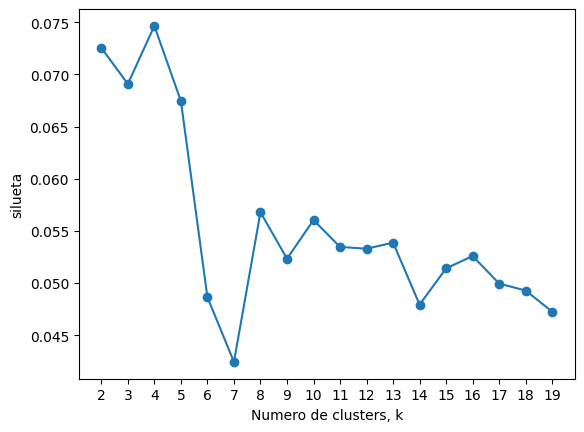

In [30]:
#Método de la rodilla: silueta
from sklearn import metrics

ks = range(2, 20) # crear valores del 2 al 20
siluetas = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k, max_iter=300, random_state=42, n_init='auto')
    model.fit(data_for_kmeans)
    sil=metrics.silhouette_score(data_for_kmeans, model.labels_)
    siluetas.append(sil)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, siluetas, '-o')
plt.xlabel('Numero de clusters, k')
plt.ylabel('silueta')
plt.xticks(ks)
plt.show()

In [33]:
#Creación de modelo de clustering con Kmeans
from sklearn.cluster import KMeans
k=7
model = KMeans(n_clusters=k, max_iter=300)
model.fit(data_for_kmeans) #100% datos

KMeans(n_clusters=7)

# 3. Evaluación del Modelo


*   Inertia: valor pequeño esperado
*   Silueta: valor positivo esperado, idealmente mayor a 0.5



In [35]:
k#Evaluación
from sklearn import metrics

#Inertia: se require valor pequeño
print('Inercia o cohesión:', model.inertia_)

#Silueta: se requiere que sea positivo, ideal 0.5-1.0
sil=metrics.silhouette_score(data_for_kmeans, model.labels_)
print('Silueta:',sil)

Inercia o cohesión: 30550.601143934247
Silueta: 0.05533409593720196


# 4. Perfilamiento

Descripción de centroides

In [37]:
#Centroides de los cluster se convierten  en un dataframe de pandas
centroides=pd.DataFrame(model.cluster_centers_, columns=data_for_kmeans.columns.values)
centroides.round(1)

,Edad,Periodo_202242,Periodo_202342,Periodo_202442,Periodo_202542,Periodo_202642,Periodo_202742,Programa Admision_Esp Cardiol Interv y Hemod-Med,Programa Admision_Esp Cardiologia Pediatrica-Med,Programa Admision_Esp Cirugia Cardiovascular-Med,...,Ciudad Residencia_YACUANQUER - NARIÑO,Ciudad Residencia_YARUMAL - ANTIOQUIA,Ciudad Residencia_YOLOMBO - ANTIOQUIA,Ciudad Residencia_YOPAL - CASANARE,Ciudad Residencia_YUMBO - VALLE DEL CAUCA,Ciudad Residencia_ZARZAL - VALLE DEL CAUCA,Ciudad Residencia_ZIPAQUIRA - CUNDINAMARCA,Ciudad Residencia_ZONA BANANERA - MAGDALENA,Naturaleza Origen Universidad_Privada,Naturaleza Origen Universidad_Publica
0,0.3,0.2,0.2,0.2,0.0,0.2,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.3,0.2,0.2,0.2,0.1,0.2,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.9
2,0.3,0.2,0.1,0.1,0.1,0.1,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,1.0
3,0.3,0.2,0.2,0.2,0.1,0.2,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0
4,0.3,0.0,-0.0,0.0,1.0,-0.0,-0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.9,0.0
5,0.3,0.2,0.2,0.1,0.0,0.1,0.2,0.0,0.0,0.0,...,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0
6,0.3,0.2,0.1,0.1,0.0,0.2,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0


In [38]:
# Se realiza una des-normalización centroides

centroides[variables_a_normalizar]=min_max_scaler.inverse_transform(centroides[variables_a_normalizar])

centroides.round(0)

,Edad,Periodo_202242,Periodo_202342,Periodo_202442,Periodo_202542,Periodo_202642,Periodo_202742,Programa Admision_Esp Cardiol Interv y Hemod-Med,Programa Admision_Esp Cardiologia Pediatrica-Med,Programa Admision_Esp Cirugia Cardiovascular-Med,...,Ciudad Residencia_YACUANQUER - NARIÑO,Ciudad Residencia_YARUMAL - ANTIOQUIA,Ciudad Residencia_YOLOMBO - ANTIOQUIA,Ciudad Residencia_YOPAL - CASANARE,Ciudad Residencia_YUMBO - VALLE DEL CAUCA,Ciudad Residencia_ZARZAL - VALLE DEL CAUCA,Ciudad Residencia_ZIPAQUIRA - CUNDINAMARCA,Ciudad Residencia_ZONA BANANERA - MAGDALENA,Naturaleza Origen Universidad_Privada,Naturaleza Origen Universidad_Publica
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,-0.0,0.0,1.0,-0.0,-0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,1.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


**PERFILAMIENTO**

Con base en la estructura de los datos de admisiones de posgrados en salud y el objetivo analítico de identificar características regionales, a continuación se presenta el perfilamiento estratégico de los 7 grupos obtenidos mediante la segmentación:

•	Cluster 1 (Jóvenes Locales de Universidades Privadas): Aspirantes con un rango de edad menor al promedio, procedentes de universidades de origen privado en Medellín y enfocados en especialidades clínicas de alta demanda.

•	Cluster 2 (Profesionales Senior del sector Público): Médicos con mayor edad y trayectoria profesional, graduados de universidades públicas, caracterizados por un alto cumplimiento en el estado de pago de admisión.

•	Cluster 3 (Aspirantes del Área Metropolitana): Residentes de municipios aledaños (como Envigado o Sabaneta) con un fuerte componente de movilidad regional hacia los programas de posgrado.

•	Cluster 4 (Perfil Foráneo Nacional): Aspirantes nacidos en otros departamentos de Colombia (por ejemplo, Santander o la Costa Caribe) que trasladan su residencia temporalmente para postularse.

•	Cluster 5 (Segmento de Alta Actividad y Registro Temprano): Caracterizados por registrarse en las primeras fechas de la convocatoria y completar rigurosamente los exámenes de admisión requeridos.

•	Cluster 6 (Segmento con Fricción en Pago): Grupo que concentra las incidencias de estado "No pago de admisión", lo que representa una oportunidad directa para campañas de mercadeo de retoma y recordatorio.

•	Cluster 7 (Perfil Internacional y Documentación Especial): Aspirantes con tipos de documento de extranjería (CE) o procedencia internacional que buscan cupos en especialidades médico-quirúrgicas específicas.


In [40]:
#En el dataframe original, se adiciona el cluster asignado a cada registro
df['cluster']=model.labels_
df.head()

,Periodo,Programa Admision,Presentan examen,Fecha Registro Admision,Estado Pago,Genero,Edad,Pais Nacimiento,Tipo Documento,Departamento Nacimiento,Ciudad Residencia,Naturaleza Origen Universidad,cluster
0,202142,Esp en Psiquiatria-Med,SI,2020-10-05 07:45:21,Pago de admision,M,41,Colombia,CC,Santander-CO,ENVIGADO - ANTIOQUIA,Publica,1
1,202142,Esp Medicina Interna-Med,SI,2020-08-31 08:03:03,Pago de admision,M,35,Colombia,CC,Antioquia-CO,ENVIGADO - ANTIOQUIA,Privada,0
2,202142,Esp Med Dol y Cui Pal-Med,SI,2020-10-02 08:10:40,Pago de admision,M,43,Colombia,CC,Norte Santander-CO,SABANETA - ANTIOQUIA,Privada,0
3,202142,Esp Dermatologia-Med,SI,2020-10-06 11:38:21,Pago de admision,M,36,Colombia,CC,Antioquia-CO,ENVIGADO - ANTIOQUIA,Publica,1
4,202142,Esp Radiologia e Imag Diag-Med,SI,2020-09-11 09:01:34,Pago de admision,M,35,Colombia,CC,Antioquia-CO,MEDELLIN - ANTIOQUIA,Privada,0


<Axes: ylabel='count'>

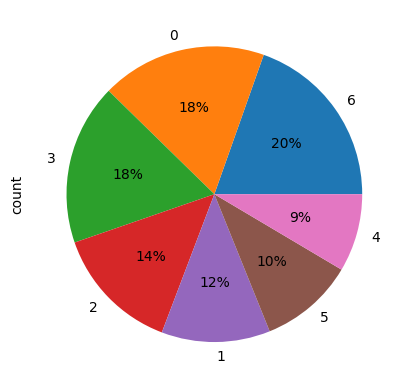

In [42]:
#Cantidad de datos en cada cluster
df["cluster"].value_counts().plot(kind='pie',autopct='%.0f%%')


In [43]:
#Almacenar resultados
df.to_excel('./resultados_Kmeans.xlsx')
centroides.to_excel('./centroides.xlsx')
